In [1]:
import sys
print(sys.executable)

/bin/python3


In [2]:
#import

import os
import random
import shutil
import numpy as np
import sys

import tifffile as tiff
import torch

In [ ]:
# =========================
# PATH SETUP
# =========================

import os

RAW_PATH = "../data/raw/EuroSAT_MS"
SPLIT_PATH = "../data/split"

# create split folder 
os.makedirs(SPLIT_PATH, exist_ok=True)

print("Current working directory:", os.getcwd())
print("RAW exists:", os.path.exists(RAW_PATH))
print("SPLIT path:", SPLIT_PATH)

# show available folders inside raw
print("Folders inside RAW:", os.listdir(RAW_PATH))

Current working directory: /home/rahuljana/Desktop/Land_classification_project/notebooks
RAW exists: True
SPLIT path: ../data/split
Folders inside RAW: ['River', 'Forest', 'AnnualCrop', 'Pasture', 'Highway', 'Industrial', 'SeaLake', 'Residential', 'HerbaceousVegetation', 'PermanentCrop']


Class: Highway
Shape: (64, 64, 13)


(-0.5, 63.5, 63.5, -0.5)

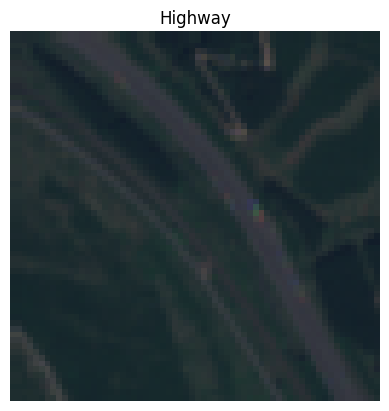

In [14]:
# =========================
# SHOW 1 MULTISPECTRAL IMAGE
# =========================

import random
import tifffile as tiff
import matplotlib.pyplot as plt

# pick random class
cls = random.choice(os.listdir(RAW_PATH))

# pick random image
img_path = os.path.join(
    RAW_PATH,
    cls,
    random.choice(os.listdir(os.path.join(RAW_PATH, cls)))
)

# load image
img = tiff.imread(img_path)

print("Class:", cls)
print("Shape:", img.shape)   # expected: (64, 64, 13)

# normalize for display
img_vis = (img - img.min()) / (img.max() - img.min() + 1e-6)

# show (band 3,2,1)
plt.imshow(img_vis[:, :, [3,2,1]])
plt.title(cls)
plt.axis("off")

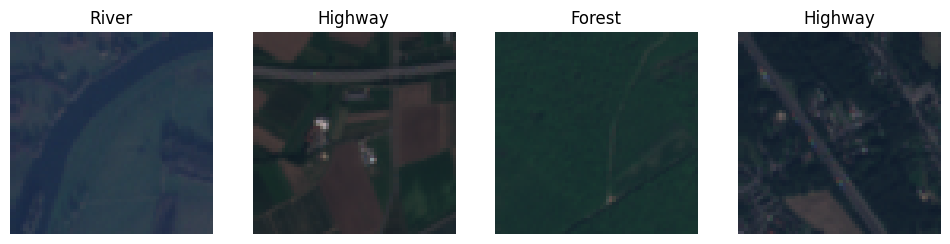

In [15]:
# =========================
# SHOW MULTIPLE IMAGES
# =========================

fig, axes = plt.subplots(1,4, figsize=(12,3))

classes = os.listdir(RAW_PATH)

for i in range(4):
    cls = random.choice(classes)

    img_path = os.path.join(
        RAW_PATH,
        cls,
        random.choice(os.listdir(os.path.join(RAW_PATH, cls)))
    )

    img = tiff.imread(img_path)

    # normalize
    img_vis = (img - img.min()) / (img.max() - img.min() + 1e-6)

    axes[i].imshow(img_vis[:, :, [3,2,1]])
    axes[i].set_title(cls)
    axes[i].axis("off")

plt.show()

In [16]:
#Dataset split

train_ratio = 0.7
val_ratio = 0.15

for cls in os.listdir(RAW_PATH):
    cls_path = os.path.join(RAW_PATH, cls)
    images = os.listdir(cls_path)
    random.shuffle(images)

    t = int(len(images)*train_ratio)
    v = int(len(images)*(train_ratio+val_ratio))

    splits = {
        "train": images[:t],
        "val": images[t:v],
        "test": images[v:]
    }

    for split in splits:
        save_dir = os.path.join(SPLIT_PATH, split, cls)
        os.makedirs(save_dir, exist_ok=True)

        for img_name in splits[split]:
            shutil.copy(os.path.join(cls_path, img_name),
                        os.path.join(save_dir, img_name))

print("✅ Dataset Split Completed")

✅ Dataset Split Completed


In [17]:
#verify split data

for split in ["train","val","test"]:
    total = 0
    for cls in os.listdir(os.path.join(SPLIT_PATH, split)):
        total += len(os.listdir(os.path.join(SPLIT_PATH, split, cls)))
    print(split, total)

train 18900
val 4050
test 4050
